# CAPs Time Series Analysis on tDCS ON data

Down-sampling time-series, concatenating and z-scoring time-series. <br>
This notebook runs the analysis only on scans for which tDCS was On (runs_str="On").

### Imports and Configuration

In [1]:
import os
from dotenv import load_dotenv
from nilearn import image, signal, masking
from nilearn.maskers import NiftiMasker
from nilearn.maskers import NiftiLabelsMasker
from nilearn.interfaces.fmriprep import load_confounds
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.stats import zscore
import time

In [2]:
load_dotenv()

subs = ['Y01', 'Y02', 'Y03', 'Y04', 'Y05', 'Y06', 'Y07', 'Y08', 'Y09','Y10',
        'Y11', 'Y12', 'Y13', 'Y14', 'Y15', 'Y16', 'Y17','Y18', 'Y19', 'Y20']
sessions = [1, 2, 3]
runs = [2]
sessions_dict = {1: "Unilateral", 2: "Bilateral", 3: "Sham"}
runs_dict = {1: "tDCS Off", 2: "tDCS On"}

base_dir = os.environ['BASE_DIR']
downsampled_ts_dir = os.environ['DOWNSAMPLED_TS_DIR']
input_dir = os.environ['INPUT_DIR']

runs_str = "run-ON"
output_dir =  os.path.join(base_dir, f"coactivation_patterns_{runs_str}")
os.makedirs(output_dir, exist_ok=True)

### Step 1: Create numpy files (timepoints × voxels/ROIs)

Schaefer 2018 parcellation for **cortical** voxels in the MNI152 space

[fetch_atlas_schaefer_2018] Dataset found in C:\Users\user\nilearn_data\schaefer_2018

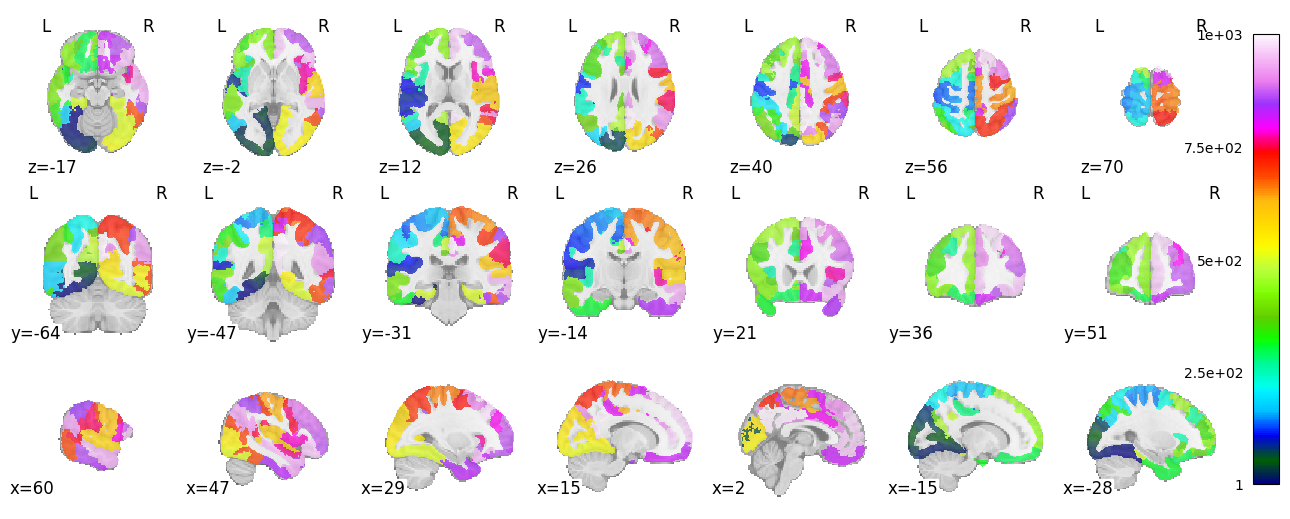

In [3]:
from nilearn import datasets
from nilearn import plotting

schaefer_atlas = datasets.fetch_atlas_schaefer_2018(n_rois=1000, yeo_networks=7, resolution_mm=1)

masker = NiftiLabelsMasker(
    labels_img=schaefer_atlas.maps,
    standardize=True,
    memory='nilearn_cache',
    verbose=5
)

plotting.plot_roi(schaefer_atlas.maps, display_mode="mosaic")

KH atlas: Schaefer 2018 parcellation for cortical voxels in the MNI152 space + subcortical and cerebellar parcellation

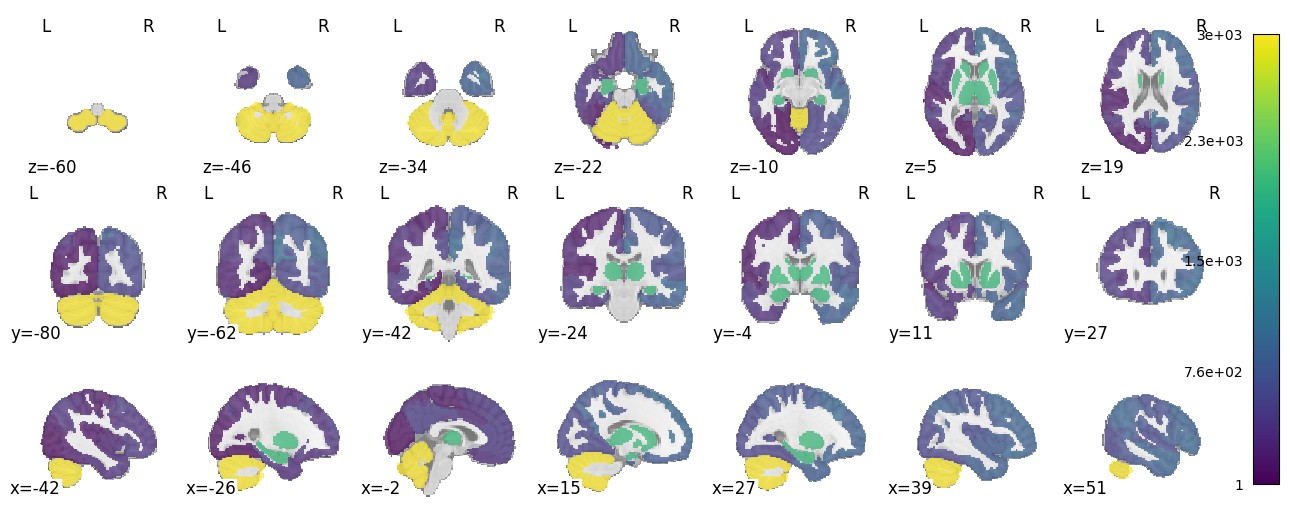

In [4]:
atlas_dir = os.environ['ATLAS_DIR']
atlas_filename = os.path.join(atlas_dir, "atlas_combined_tpl-MNI152NLin2009cAsym_res-02_T1w.nii.gz")
atlas_infos = pd.read_csv(os.path.join(atlas_dir, "atlas_combined_labels.csv"))

atlas_masker = NiftiLabelsMasker(labels_img=atlas_filename, mask_img=None, standardize=False, standardize_confounds=True, memory="nilearn_cache", verbose=0)
atlas_masker.fit()

plotting.plot_roi(atlas_filename, display_mode="mosaic", cmap="viridis")

Shape of masked np array after applying atlas: 379, 1060. <br>
Schafer 1000 + 30 subcortex + 30 cerebellar

Downsample each subject's data based on the KH atlas, save the time-series as numpy file (no need to run more than once)

In [5]:
# # Process each subject's data less than 30 seconds per file - run one time
# for sub in subs:
#     for ses in sessions:
#         for run in runs:

#             ses_name = sessions_dict[ses]

#             # Define input and output filenames
#             vol_filename = f"sub-{sub}_ses-{ses}_run-{run}_denoised_simple.nii.gz"
#             ts_output_filename = f"sub-{sub}_ses-{ses}_run-{run}_1060-ROIs_timeseries.npy"

#             # Create full paths
#             vol_img_path = os.path.join(input_dir, vol_filename)
#             ts_output_path = os.path.join(downsampled_ts_dir, ts_output_filename)

#             # Check if input file exists
#             if not os.path.exists(vol_img_path):
#                 print(f"Warning: File not found: {vol_img_path}")
#                 continue

#             print(f"\nProcessing: Subject {sub}, {ses_name} session, {runs_dict[run]}")

#             try:
#                 # Extract time series using the atlas-based masker
#                 time_series = atlas_masker.fit_transform(vol_img_path)

#                 # Save the extracted time series
#                 np.save(ts_output_path, time_series)
#                 print(f"Saved: {ts_output_filename}")
#                 print(f"Shape: {time_series.shape} (timepoints x ROIs)")

#             except Exception as e:
#                 print(f"Error processing {vol_img_path}: {str(e)}")
#                 continue

### Step 2: Concatenate time*ROIs matrices and z-score time series of each ROI

In [6]:
start_time = time.time()
CAP_TS = np.array([])  #the concatenated z-scored time-series data for all subjects, sessions, and runs
DATA_LABELS = np.array([])  #the identifier labels for the data (subject, session, run)
tmp_concat_dat = np.array([])  #for concatenating z-scored data within a subject
tmp_data_labels = np.array([])  #for concatenating labels within a subject

for sub in subs:
    for ses in sessions:
        for run in runs:
            data_label = f"sub-{sub}_ses-{ses}_run-{run}"
            print(f"\nProcessing: Subject {sub}, {ses}, {run}")
            filename = f"sub-{sub}_ses-{ses}_run-{run}_1060-ROIs_timeseries.npy"
            filepath = os.path.join(downsampled_ts_dir, filename)

            bold_data = np.load(filepath)  # timepoits*voxels
            # z-score the data across time points (axis=0) for each voxel
            bold_zscored = zscore(bold_data, axis=0, nan_policy='omit')

            # changed to nanmean and nanstd
            print(np.nanmean(bold_zscored[:, 0]), np.nanstd(bold_zscored[:, 0]), bold_zscored[:, 0].shape, bold_zscored.shape)

            tmp_concat_dat = np.concatenate((tmp_concat_dat, bold_zscored)) if tmp_concat_dat.size else bold_zscored
            data_label_array = np.repeat(data_label, bold_zscored.shape[0])
            tmp_data_labels = np.concatenate((tmp_data_labels, data_label_array)) if tmp_data_labels.size else data_label_array

    # once all sessions and runs for the current subject are processed:
    # concatenate the subject's data into the main arrays (CAP_TS and DATA_LABELS)
    CAP_TS = np.concatenate((CAP_TS, tmp_concat_dat)) if CAP_TS.size else tmp_concat_dat
    tmp_concat_dat = np.array([])
    DATA_LABELS = np.concatenate((DATA_LABELS, tmp_data_labels)) if DATA_LABELS.size else tmp_data_labels
    tmp_data_labels = np.array([])

    print(f"Finished processing subject {sub}")

print(f"Total time taken: {time.time() - start_time:.2f} seconds")
print(CAP_TS.shape)

np.save(os.path.join(output_dir, f"DATA_LABELS_{runs_str}.npy"), DATA_LABELS)

#After processing all data, the cumulative CAP_TS is z-scored again across all time points for each voexl
CAP_TS = zscore(CAP_TS, axis=0, nan_policy='omit')
np.save(os.path.join(output_dir, f"CAP_TS_{runs_str}_zscored.npy"), CAP_TS)


Processing: Subject Y01, 1, 2
-8.3717e-05 0.9999999 (379,) (379, 1060)

Processing: Subject Y01, 2, 2
0.00026319336 1.0 (379,) (379, 1060)

Processing: Subject Y01, 3, 2
3.8924507e-05 1.0000001 (379,) (379, 1060)
Finished processing subject Y01

Processing: Subject Y02, 1, 2
0.00016856383 0.9999998 (379,) (379, 1060)

Processing: Subject Y02, 2, 2
8.092644e-05 0.99999976 (379,) (379, 1060)

Processing: Subject Y02, 3, 2
0.00015431784 1.0 (379,) (379, 1060)
Finished processing subject Y02

Processing: Subject Y03, 1, 2
-0.00031531518 1.0 (379,) (379, 1060)

Processing: Subject Y03, 2, 2
0.00022843896 0.99999994 (379,) (379, 1060)

Processing: Subject Y03, 3, 2
-9.0919886e-05 0.99999976 (379,) (379, 1060)
Finished processing subject Y03

Processing: Subject Y04, 1, 2
0.00013799813 0.9999999 (379,) (379, 1060)

Processing: Subject Y04, 2, 2
-9.1450194e-05 0.9999999 (379,) (379, 1060)

Processing: Subject Y04, 3, 2
-3.6435893e-05 1.0000001 (379,) (379, 1060)
Finished processing subject Y0

Make sure that the dimensions of the concatenated data match what we would expect

In [7]:
CAP_TS.shape

(22740, 1060)

In [8]:
num_timepoints = 379
num_timepoints*len(subs)*len(sessions)*len(runs)

22740

Check the std and plot the time-series of the first  ROI

-2.9356728e-10 1.000001 (22740,) (22740, 1060) (22740,)
(379,)


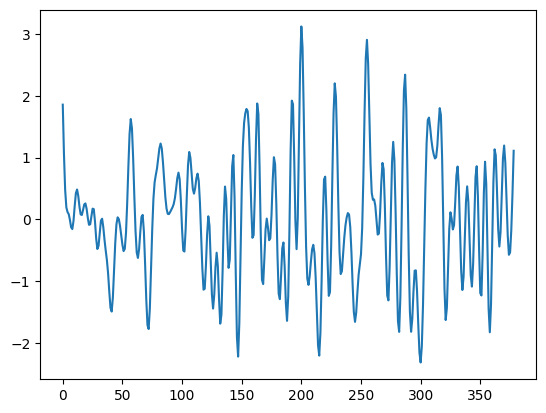

In [9]:
print(np.mean(CAP_TS[:,0]), np.std(CAP_TS[:,0]), CAP_TS[:,0].shape, CAP_TS.shape, DATA_LABELS.shape)
print(CAP_TS[0:num_timepoints, 0].shape)
plt.plot(CAP_TS[0:num_timepoints, 0])